# Classifying Various Images from the CIFAR-10 Dataset



## 1.0 Introduction
This project discusses the designing, implementing, and evaluating processes involved in machine learning, specifically for classifying images. Various models were developed using convolution blocks featuring convolution, activation, and pooling layers, which will then be improved on using a variety of techniques.

The dataset involved is the CIFAR-10 dataset which will be accessed through the *torchvision.datasets* repository.

In [2]:
# Imports
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score


In [ ]:
import sys
import functions

In [4]:
# this is for reimporting ModelBuilder when changes are made to it
# since Colab was used for this assignment, this was accessed through Google Drive
sys.modules.pop('ModelBuilder', None)

import importlib
import ModelBuilder
importlib.reload(ModelBuilder)

from ModelBuilder import ModelBuilder


These imports include a line that triggers the Model Builder file to be reloaded, this was utilised in later stages when the Model Builder was being altered. The Functions file was also later  reloaded but this was performed within the relevant section for simplicity.

## 2.0 Data Preparation
The CIFAR-10 dataset contains a train set and a test set, by marking as "True", only the neccessary train set will be downloaded. Through setting transform to transform.ToTensor() the data is converted to tensors as it is downloaded. A simple check, printing the length of the downloaded dataset, was performed to validate that only the train set (containing 50,000 images) was downloaded.



In [5]:
# Downloading Dataset
transform = transforms.ToTensor()

data_directory = "/content/drive/MyDrive/cifar/cifar_data"

train_dataset = torchvision.datasets.CIFAR10(
    root=data_directory,
    train=True,
    download=True,
    transform=transform
)

# Check Download
len(train_dataset)

50000

In [6]:
# Splitting into test, train, and validation sets
sizes = [15000, 5000, 5000, 25000]

train_set, val_set, test_set, leftover_set = random_split(
    train_dataset,
    sizes,
    generator=torch.Generator().manual_seed(42)
)

This splitting process takes into account the provided amounts of 15,000 for the train set, 5000 for the validation set, and 5000 for the test set. A "leftover" set of the remaining images not placed into the prior sets is created with an amount of 25,000 to allow for the splitting to be done effectively.

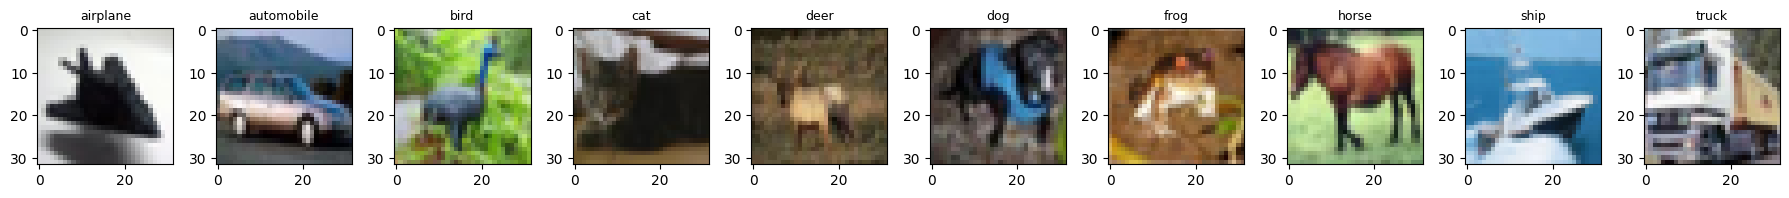

In [7]:
# warm up to familiarise with dataset
titles = train_dataset.classes

fig, axes = plt.subplots(1, 10, figsize=(18, 2))


# finds first matching image
for class_id in range(10):
    idx = next(i for i, (_, label) in enumerate(train_dataset) if label == class_id)

    img, _ = train_dataset[idx]
    img = np.transpose(img.numpy(), (1, 2, 0))   # C×H×W → H×W×C

    axes[class_id].imshow(img)
    axes[class_id].set_title(titles[class_id], fontsize=9)

plt.tight_layout()
plt.show()


This warm up exercise provided a deeper understanding of what the dataset looks likr through effectively visualising a small sample. The order of the images will be utilised later.

There were three different possible versions this assignment could be implemented through. It was essential to calculate the specific version following assignment instructions before continuing.


**Calculation of Version:**

SRN: 2340035

35/3 = 11, Remainder = 2

Therefore, Version 2 will be implemented.

**CIFAR-10 Class Grouping for Version 2:**

class 0: automobile, truck

class 1: frog

class 2: dog

class 3: horse, bird, deer

class 4: cat

Now this version will be implemented onto our sets. This implementation will consider the desired labels for version 2 above, as well and the 10 CIFAR class labels, these orginal labels were found based on the order of the images above and have been rewritten below for readability.

**CIFAR-10 Original Class Labels:**

CIFAR class 0: airplane

CIFAR class 1: automobile

CIFAR class 2: bird

CIFAR class 3: cat

CIFAR class 4: deer

CIFAR class 5: dog

CIFAR class 6: frog

CIFAR class 7: horse

CIFAR class 8: ship

CIFAR class 9: truck

In comparison to these original labels, the version 2 class groups do not include airplane (orignal label = 0) or ship (original label = 8), therefore, these will not be applied below.


In [8]:
version2 = {
    1: 0,
    2: 3,
    3: 4,
    4: 3,
    5: 2,
    6: 1,
    7: 3,
    9: 0
}

Now that these class labels have been defined, the data contained in the train set, the validation set, and the test set can be remapped to these new labels. This was performed using a function that was developed for remapping, this function takes in two variables, a set, and the chosen version. The leftover set will be ignored since it is not actually going to be used and was just used for calculation purposes.

In [9]:
# there is a function in our functions.py that we can use to remap the labels according to the dictionary, this will be called.
train_v2 = functions.remap_dataset(train_set, version2)
val_v2 = functions.remap_dataset(val_set, version2)
test_v2 = functions.remap_dataset(test_set, version2)

## 3.0 Model Design and Training
Firstly, data loaders for the remapped train set and the remapped validation set needed to be developed. These are essential in guaranteeing that the data is prepared and formatting properly in order to be delivered to a model. A batch size of 64 was initially chosen, however, this was later altered during model experimentation.

In [10]:
batch_size = 64

# create loaders
train_loader = DataLoader(train_v2, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_v2, batch_size=batch_size, shuffle=False)

print(len(train_loader), len(val_loader))


187 63


In [11]:
# count frequency of each class label in batches for batch_size = 64
images, labels = next(iter(train_loader))
frequency = Counter(labels.tolist())

print(frequency)

Counter({3: 27, 0: 14, 1: 9, 4: 8, 2: 6})


These frequencies of how many samples there are in each class are as expected. Class 3 has the largest frequency of 39 since it contains three different image types: horse, bird, and deer. Unsuprisingly, class 0 has the next largest frequency with 27 counts, this is because it contains two image types: automobile and truck. The other three classes are all smaller and approximately the same size as they each only contain one image type.

#### 3.1 Designing of the Sequential Model
As instructed this sequential model must include two convolution blocks, each containing a convolution layer followed by an activation layer and a pooling layer, and fully connected layers so that the images can be effectively classified.

In [14]:
m2 = nn.Sequential(

    nn.Conv2d(in_channels=3, out_channels=20, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(in_channels=20, out_channels=40, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),

    nn.Linear(40 * 8 * 8, 200),
    nn.ReLU(),

    nn.Linear(200, 5)
)

torch.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(m2.parameters(), lr=0.0005)

mb_m2 = ModelBuilder(m2, loss_fn, optimizer, print_loss_freq=2)
mb_m2.set_loaders(train_loader, val_loader)

history_m2 = mb_m2.train(
    n_epochs=18,
    seed=42
)



Epoch 2, Training loss 1.0028, Validation loss 0.9831
Epoch 4, Training loss 0.8717, Validation loss 0.8740
Epoch 6, Training loss 0.7908, Validation loss 0.8482
Epoch 8, Training loss 0.7377, Validation loss 0.8029
Epoch 10, Training loss 0.6722, Validation loss 0.7851
Epoch 12, Training loss 0.6185, Validation loss 0.7778
Epoch 14, Training loss 0.5640, Validation loss 0.8262
Epoch 16, Training loss 0.5142, Validation loss 0.7741
Epoch 18, Training loss 0.4628, Validation loss 0.8009


**Layer Shape Analysis:**

This sequential model was made with a high consideration on shape flow to guarantee that it would output successfully. For this shape flow consider how each tensor in a convolutional neural network has the shape of (channels, height, width). We know that the input is (3, 2, 32) because of the fixed image size of the CIFAR-10 dataset.

-	The first convolution block takes the 3 input channels and outputs 20, with a kernel size of 5 and padding = 2. When put into the output size formula, since the padding value was specifically chosen to keep the width and height the same, this has the output shape of (20, 32, 32). It was decided to make this padding value keep those values the same in order to make the later pooling layers control the spatial size reduction rather than the convolution layers. This kernel size was chosen so that larger spatial features could be captured.
-	The activation layer (ReLU) does not change the size.
-	The pooling layer, with kernel = 2 and stride = 2, halves the width and height to output the shape of (20, 16, 16). This is because the kernel looks at 2 x 2 patches moving 2 pixels at a time, therefore skipping half the image since for each 2 x 2 area, only one number is being outputted. This can be calculated simply using the output size formula.
-	For the second convolution block, the same output size formula is used for the convolution layer, based on this formula padding was chosen to equal 1 so that the width and height would remain the same again, resulting in an output shape of (40, 16, 16), with just the number of channels outputting to 40. For the next two layers, again the activation layer does not change the shape, and the pooling layer halves the height and width. This results in a shape of (40, 8, 8).
-	When flattened, this vector size is 2560, now that this value is known, it must be specified in the first linear layer so that each sample is confirmed to have the right size before entering.
-	The final layer needs to output 5 channels since this is the number of classes stated in version 2, if this output number did not match, the images would not be able to correctly be classified into the classes. Therefore, the first linear layer was chosen to output 200 channels, as this is as a good middle ground between 2560 and 5.

This model occassionally met the needed validation loss for the task, however, it was inconsistent. To easily improve this, the model was redeveloped to be slightly deeper.

#### 3.2 Training the Sequential Model

In [17]:
m2 = nn.Sequential(
     nn.Conv2d(3, 32, kernel_size=3, padding=1),
     nn.ReLU(),
     nn.MaxPool2d(2,2),

     nn.Conv2d(32, 64, kernel_size=3, padding=1),
     nn.ReLU(),
     nn.MaxPool2d(2,2),

     nn.Flatten(),
     nn.Linear(64*8*8, 512),
     nn.ReLU(),
     nn.Linear(512, 5)
 )

torch.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(m2.parameters(), lr=0.0005)

mb_m2 = ModelBuilder(m2, loss_fn, optimizer, print_loss_freq=2)
mb_m2.set_loaders(train_loader, val_loader)

history_m2 = mb_m2.train(
    n_epochs=12,
    seed=42
)



Epoch 2, Training loss 0.9218, Validation loss 0.9209
Epoch 4, Training loss 0.7635, Validation loss 0.7850
Epoch 6, Training loss 0.6536, Validation loss 0.7218
Epoch 8, Training loss 0.5796, Validation loss 0.7178
Epoch 10, Training loss 0.5006, Validation loss 0.7203
Epoch 12, Training loss 0.4247, Validation loss 0.7362


The same calculations used previously for determining how to achieve the desired shape of the model were reapplied for this deeper model to guarantee that the images could be successfully classified instead of outputting errors.

**Layer Shape Analysis:**
- The input shape was again (3, 32, 32)
- For the first convolution block, the convolution layer was calculated to need a padding of 1 for the height and width to remain the same. Considering the output amount of channels was selected as 32, the shape was now (32, 32, 32).The 3x3 kernel was selected as this is a more efficient size for deep learning, making sure that details can be retained.
- ReLU causes no shape change.
- MaxPool2d halved the height and width, resulting in a shape of (32, 16, 16).
- The second convolution block followed a similar pattern leading to an output shape of (64, 8, 8).
- This was then flattened, equalling a size of 4096.
- The following linear layers reduced this to 512, and then to 5, as needed considering the amount of classes instructed by version 2.

This deeper model was meeting the required loss very easily, and with significantly more stability and consistency. Although the amount of epochs selected for this model is quite small, it is actually quite suitable. When run for longer to model would quickly overfit to the training data due to the model memorising this set rather than learning features. This was happening very quickly due to the simpe architecture and since this version of the dataset is quite reduced. By limiting the epochs to a smaller  amount, the validation performance peak was able to be captured more effectively.

#### 3.3 Graph of Losses

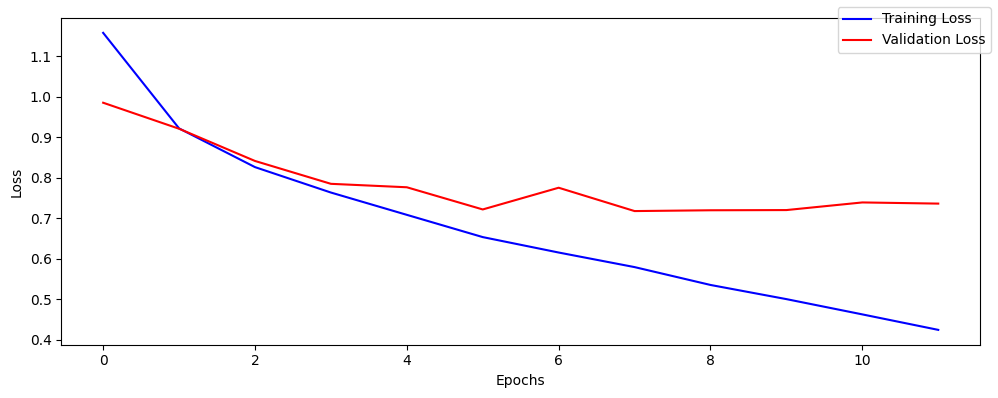

In [18]:
mb_m2.plot_losses()

This graph of losses displays how both training and validation decrease intitally, demonstrating how in early training phases the learning generalises well. As expected, the training loss continues to decrease. The validation loss on the other hand plateaus and becomes less stable, a clear indication of overfitting considering how the training loss is improving. The gap begins between the two with a final validation loss of 0.7362 and a final training loss of 0.4247, this overfitting could be minimised easily through regularisation.

#### 3.4 Confusion Matrices

The following code was developed to produce confusion matrices through collecting the true labels and the predicted labels and comparing them. Both the raw counts and the normalised counts were placed into matrices as they provide different insights.

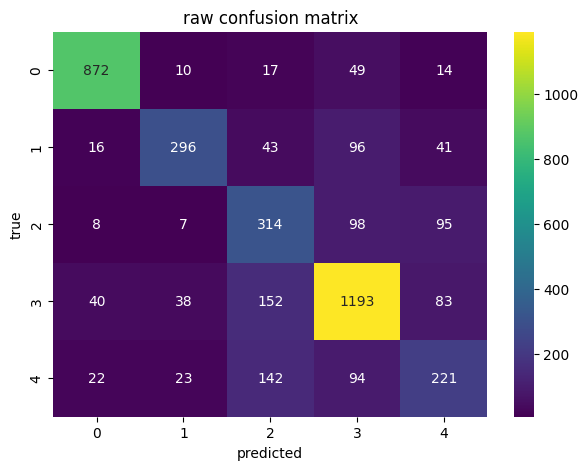

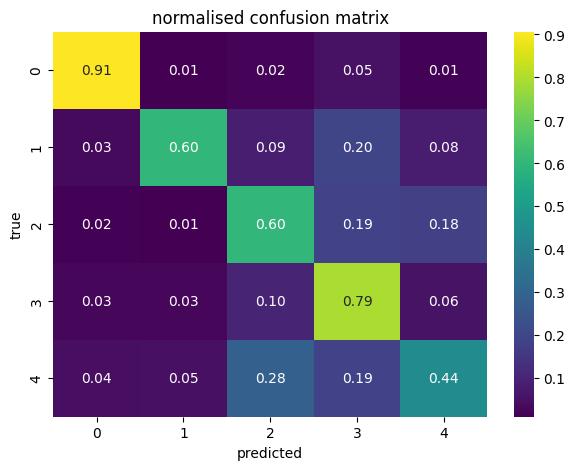

In [19]:
# collecting true labels and predicted labels

pred_labels = []
true_labels = []

m2.eval() # this is used for accuracy and confusion matrices results (evaluation)
with torch.no_grad(): # for efficiency

    # loop through each image and label in the validation set
    for images, labels in val_loader:
        images = images.to(mb_m2.device)
        labels = labels.to(mb_m2.device)

        outputs = m2(images) # get the model's predictions
        preds = torch.argmax(outputs, dim=1) # choose class with highest score

        # add labels to the lists
        pred_labels.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# confusion matrices

cm_raw = confusion_matrix(true_labels, pred_labels)

cm_norm = confusion_matrix(true_labels, pred_labels, normalize='true')

# raw
plt.figure(figsize=(7,5))
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="viridis")
plt.title("raw confusion matrix")
plt.xlabel("predicted")
plt.ylabel("true")
plt.show()

# normalised
plt.figure(figsize=(7,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="viridis")
plt.title("normalised confusion matrix")
plt.xlabel("predicted")
plt.ylabel("true")
plt.show()


The raw confusion matrix displays the actual number of samples that were predicted for each cell, this is beneficial for showing classes with higher amounts of samples, very relevant considering the imbalance in the dataset.

The normalised matrix shows percentages, showing what percentage were classifed correctly so that different cells can be compared more accurately.

For these specific results, the raw confusion matrix shows how (unsuprisingly) class 3, with the highest frequencies, also has the most correct predictions. Class 0 also had a high amount of correct counts, probably for this same reason.

The normalised confusion matrix shows that class 0 had the highest accuracy, with a score of 91%, this is very strong and probably due to the expected distinctions between this class containing vehicles rather than animals. Class 3 also had a really good score of 79%. 10% of the predicted class 3 images were from class 2, this is probably due to the visually similar shapes of horses and deers with dogs. Class 1 and 2 had moderate accuracies of 60% however there were many instances of them being misclassified into class 3. Class 4 had the lowest accuracy of 44% with lots of misclassifications into class 2, the dog class. This is unsuprising considering the visual similarities between these two classes.



#### 3.5 Overall Validation Accuracy

In [20]:
val_acc = accuracy_score(pred_labels, true_labels)
print(val_acc)

0.7269076305220884


Overall, the validation accuracy is around 72.7%, which is quite good. However this score would definitely be unfairly impacted by the strong accuracy of class 0, and therefore in later comparisons its important to not use just this score but the matrices as well.

#### 3.6 Altering Model Builder

The *ModelBuilder* was modified to include a *plot_accuracies* method that plots graphs of model accuracy of train and validation sets.

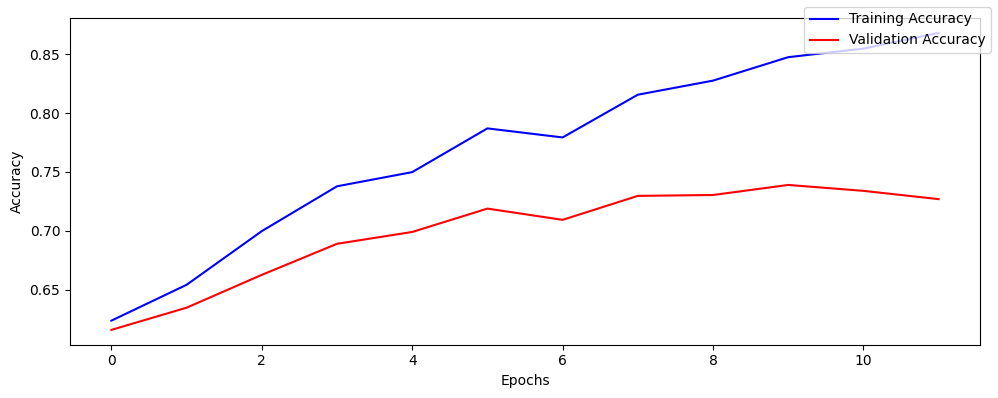

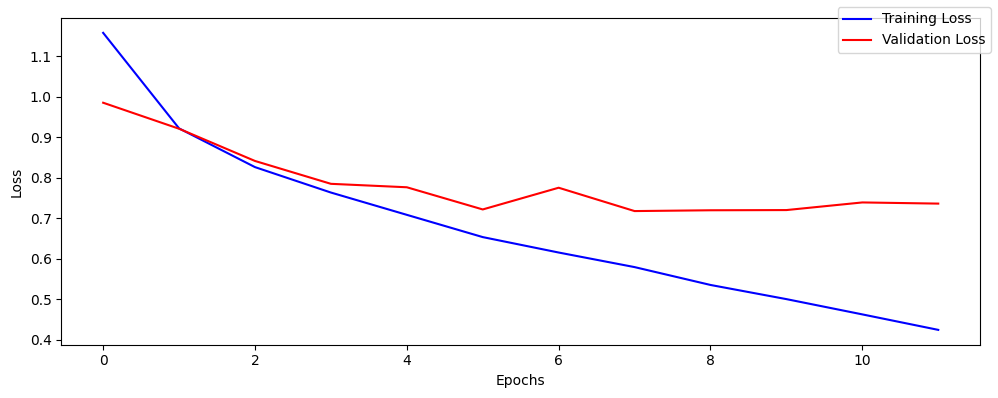

In [67]:
mb_m2.plot_accuracies()
mb_m2.plot_losses()

Although these two graphs look like they are displaying similar information, when paired together, they are actually quite valuable. The accuracy graph shows how well the model performs, helpful in identifying when improvement stops. The loss graph shows the confidence of the model and how it is learns internally. Accuracy provides a correctness score whilst loss measures how wrong the answers were. Both are beneficial in this case for idenitifying when the overfitting begins to occur.

When plotted together these graphs show how the validation begins to plateau after 5 epochs with the gap widening later. This model learns quickly but after this moment the accuracy stops improving significantly and the loss becomes significantly more unstable.

## 4.0 Model Evaluation

In [22]:
test_loader = DataLoader(test_v2, batch_size=64, shuffle=False)
test_pred_labels = []
test_true_labels = []

m2.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(mb_m2.device)
        labels = labels.to(mb_m2.device)

        outputs = m2(images)
        preds = torch.argmax(outputs, dim=1)

        test_pred_labels.extend(preds.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())


test_acc = accuracy_score(test_true_labels, test_pred_labels)
print(test_acc)


0.7407592407592407


This score, which is very close to the validation accuracy of around 0.72, means that the model is likely good and reliable, with it not being heavily overfitted to its training.

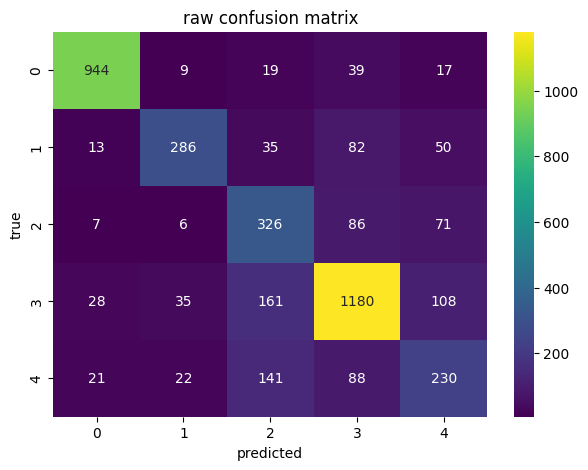

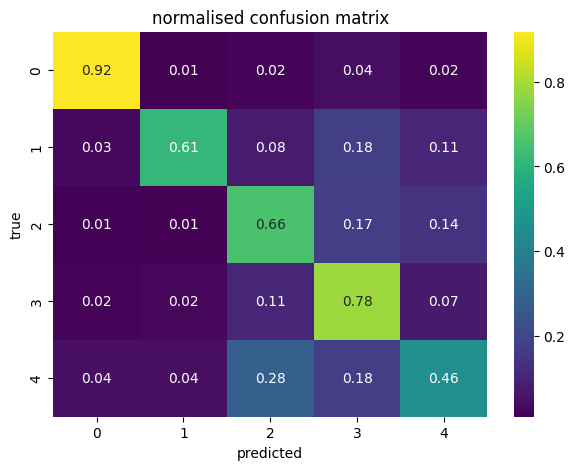

In [23]:
# confusion matrices

cm_raw = confusion_matrix(test_true_labels, test_pred_labels)

cm_norm = confusion_matrix(test_true_labels, test_pred_labels, normalize='true')

# raw
plt.figure(figsize=(7,5))
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="viridis")
plt.title("raw confusion matrix")
plt.xlabel("predicted")
plt.ylabel("true")
plt.show()

# normalised
plt.figure(figsize=(7,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="viridis")
plt.title("normalised confusion matrix")
plt.xlabel("predicted")
plt.ylabel("true")
plt.show()

Unsuprisingly, considering the similar results for the accuracy score, these matrices are also quite similar. Both the validation and test confusion matrices showed the same patterns of mistakes, which displays stable behaviour.

These test confusion matrices are very valuable as they confirm that the model has not accidentally overfitted to the validation set, this is important considering the small hyperparamter tuning that was also performed. Through idenitifying the same patterns, the model is exposed as consistently biased, meaning the improvements made should pureposefully target the issues through class balancing or dropout.

Another benefit of comparing these two lies in security. If there had been data leakage the test matrices would have been significantly worse, since they are not, there can be confirmed to be no leakage meaning the model was trained and validated correctly.

## 5.0 Deeper Model
#### 5.1 Designing and Training m3

This model was designed in a very similar manner to the previous one, just with the introduction of another convolution block. This third convolution block provides more depth and will be beneficial in learning more high-level features and patterns. The increase in channels matches this level increase by keeping the channels increasing progressively to control parameter growth.

A (slightly) higher learning rate was selected for this model to help the model converge quickly despite it being a little deeper.

In [24]:
m3 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.ReLU(),
    nn.Linear(512, 5)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(m3.parameters(), lr=0.0008)

mb_m3 = ModelBuilder(m3, loss_fn, optimizer, print_loss_freq=1)
mb_m3.set_loaders(train_loader, val_loader)

history_m3 = mb_m3.train(
    n_epochs=10,
    seed=42
)


Epoch 1, Training loss 1.1876, Validation loss 1.0705
Epoch 2, Training loss 0.9261, Validation loss 0.8894
Epoch 3, Training loss 0.8007, Validation loss 0.7988
Epoch 4, Training loss 0.7305, Validation loss 0.7793
Epoch 5, Training loss 0.6679, Validation loss 0.7409
Epoch 6, Training loss 0.6034, Validation loss 0.7045
Epoch 7, Training loss 0.5488, Validation loss 0.7277
Epoch 8, Training loss 0.5002, Validation loss 0.7193
Epoch 9, Training loss 0.4220, Validation loss 0.6970
Epoch 10, Training loss 0.3721, Validation loss 0.7242


The epochs was intitally set to 40 epochs, however, this was leading to rapid overfitting after  15th epochs. It is no suprise that this overfitting is occuring quite early considering that there has not been the introduction of any normalisation, dropout, or weighted sampler. To solve this, this model was limited to just 10 epochs.

#### 5.2 m3 on the Validation Set (Losses, Accuracy, Confusion Matrices)

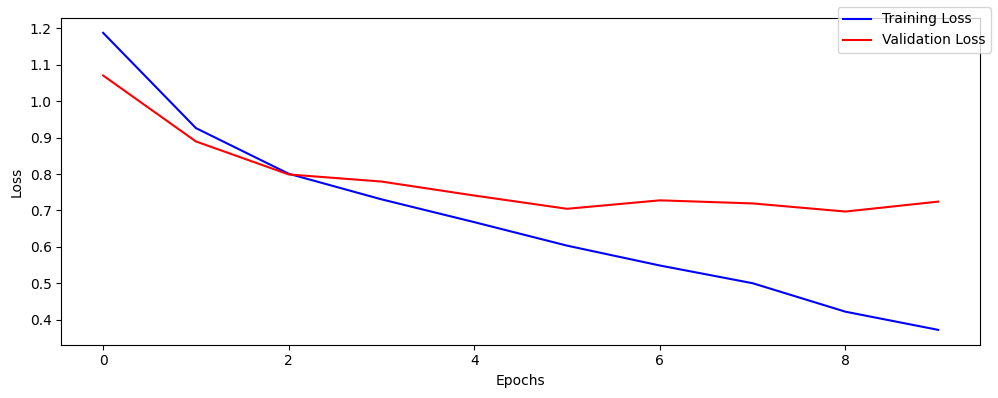

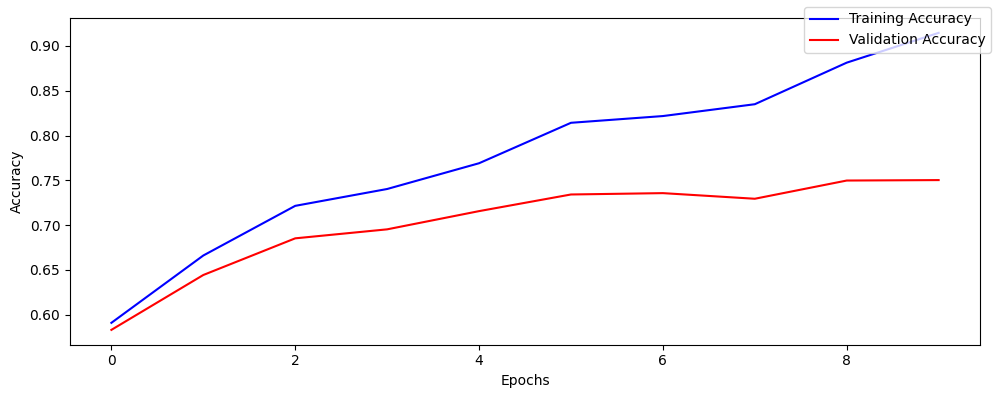

In [25]:
mb_m3.plot_losses()
mb_m3.plot_accuracies()

The training accuracy of the model rises a lot quicker than the previous model due to its increased power and depth, meaning that it learns the training data a lot quicker. However, the validation accuracy is not actually generalising that much better than the previous model, with overfitting still present.

The training loss understandably decreases smoothly whilst the validation loss falls rapidly at the start before plateauing around 6 and 7 epochs. Showing how the model is overfitting quickly than the previous model.

Overall, this model does produce a slightly better accuracy on the validation set, but unsuprisingly not that signifciant. The main difference between the two models is the power and speed.

0.7502510040160643


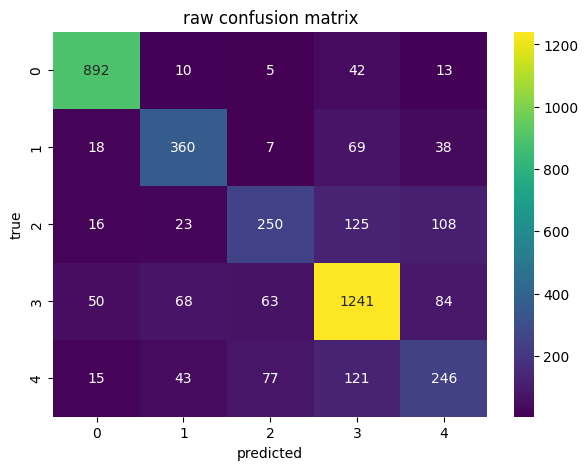

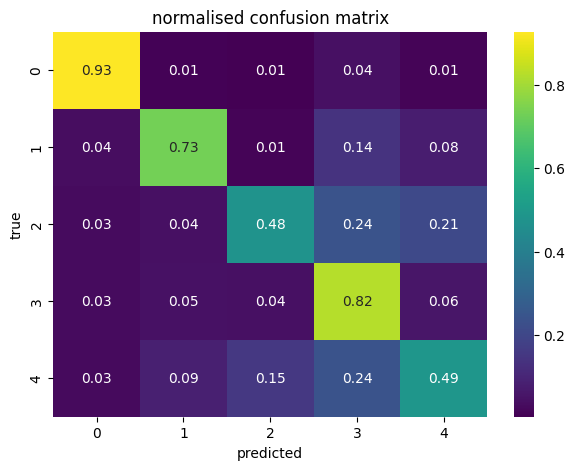

In [26]:
# collecting true labels and predicted labels

pred_labels = []
true_labels = []

m3.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(mb_m3.device)
        labels = labels.to(mb_m3.device)

        outputs = m3(images)
        preds = torch.argmax(outputs, dim=1)

        pred_labels.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

val_acc = accuracy_score(pred_labels, true_labels)
print(val_acc)

# confusion matrices

cm_raw = confusion_matrix(true_labels, pred_labels)

cm_norm = confusion_matrix(true_labels, pred_labels, normalize='true')

# raw
plt.figure(figsize=(7,5))
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="viridis")
plt.title("raw confusion matrix")
plt.xlabel("predicted")
plt.ylabel("true")
plt.show()

# normalised
plt.figure(figsize=(7,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="viridis")
plt.title("normalised confusion matrix")
plt.xlabel("predicted")
plt.ylabel("true")
plt.show()

These matrices show an improvement in most of the classes with:
- class 0 up to 93% accuracy from 91%
- class 1 up to 73% from 60%
- class 3 up to 82% from 79%
- class 4 up to 49% from 44%

However, class 2 actually got worse, possibly demonstrating an overfitting of m3 with animal themed categorisation. There was significant overflow of class 2, with it often being predicted as class 3 or class 4.


#### 5.3 m3 on the Test Set (Losses, Accuracy, Confusion Matrices)

This model now trained and validated will be evaluated through being applied to the test set that was set aside.

0.7512487512487512


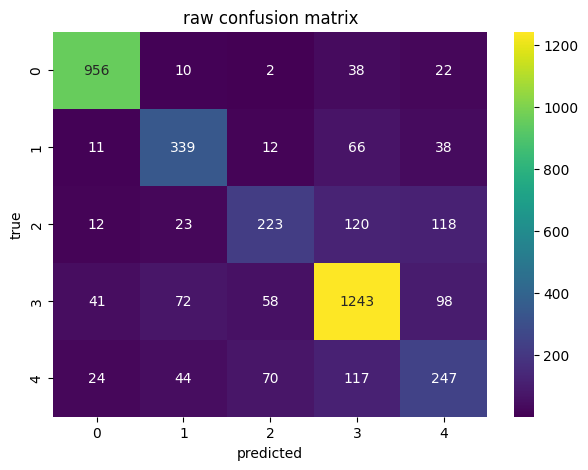

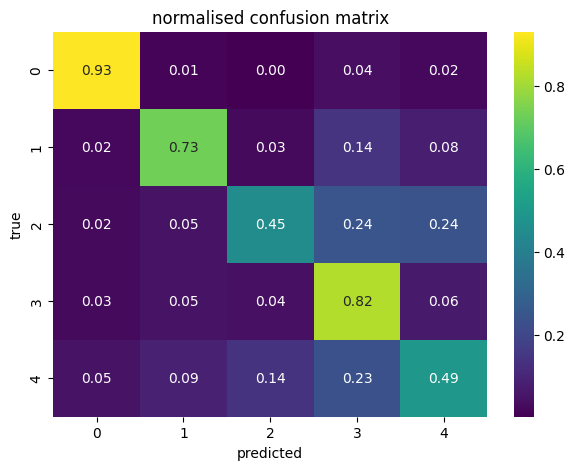

In [27]:
test_loader = DataLoader(test_v2, batch_size=64, shuffle=False)
test_pred_labels = []
test_true_labels = []

m3.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(mb_m3.device)
        labels = labels.to(mb_m3.device)

        outputs = m3(images)
        preds = torch.argmax(outputs, dim=1)

        test_pred_labels.extend(preds.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())


test_acc = accuracy_score(test_true_labels, test_pred_labels)
print(test_acc)

# confusion matrices

cm_raw = confusion_matrix(test_true_labels, test_pred_labels)

cm_norm = confusion_matrix(test_true_labels, test_pred_labels, normalize='true')

# raw
plt.figure(figsize=(7,5))
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="viridis")
plt.title("raw confusion matrix")
plt.xlabel("predicted")
plt.ylabel("true")
plt.show()

# normalised
plt.figure(figsize=(7,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="viridis")
plt.title("normalised confusion matrix")
plt.xlabel("predicted")
plt.ylabel("true")
plt.show()

Overall, these matrices produced very similar results to the validation matrices will most of the classes having no difference in accuracy, however there was a slight drop for class 2, again displaying how this class is not being learnt effectively.

The consistency of these patterns show that the model is being trained correctly with the generalisation remaining stable. This test set still shows a small increase in comparison to the previous model which is logical considering the increased depth.

## 6.0 Model Improvement

This next section will work on improving the model training through methods like feature scaling/normalisation, compensating for class imbalance, and the use of the dropout and pooling layers.

Since m3 had better accuracy, m2 has been selected for futher improvement through this section! Both were close, but m2 will probably be easier to improve as it is not learning as aggressively.


#### 6.1 Applying Feature Scaling/Normalisation

This first section followed a simple process since there are known values for the mean and std that can be used for the CIFAR-10 dataset (Ganichev, 2021). These also can be caluclated independently.

In [28]:
# adding normalisation when transforming to tensor
transform_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

In [29]:
# applying the normalisation as well in the same dataset downloading process as before
train_norm_dataset = torchvision.datasets.CIFAR10(
    root=data_directory,
    train=True,
    download=False,
    transform=transform_norm
)

# freezing the split for reproducibility
gen = torch.Generator().manual_seed(42)

train_set_norm, val_set_norm, test_set_norm, leftover_norm = torch.utils.data.random_split(
    train_norm_dataset,
    [15000, 5000, 5000, 25000],
    generator=gen
)

In [30]:
train_norm_v2 = functions.remap_dataset(train_set_norm, version2)
val_norm_v2 = functions.remap_dataset(val_set_norm, version2)
test_norm_v2 = functions.remap_dataset(test_set_norm, version2)

In [32]:
batch_size = 64

train_norm_loader = DataLoader(train_norm_v2, batch_size=batch_size, shuffle=True)
val_norm_loader   = DataLoader(val_norm_v2, batch_size=batch_size, shuffle=False)

In [35]:
m2_norm = nn.Sequential(
     nn.Conv2d(3, 32, kernel_size=3, padding=1),
     nn.ReLU(),
     nn.MaxPool2d(2,2),

     nn.Conv2d(32, 64, kernel_size=3, padding=1),
     nn.ReLU(),
     nn.MaxPool2d(2,2),

     nn.Flatten(),
     nn.Linear(64*8*8, 512),
     nn.ReLU(),
     nn.Linear(512, 5)
 )

torch.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(m2_norm.parameters(), lr=0.0005)

mb_m2_norm = ModelBuilder(m2_norm, loss_fn, optimizer, print_loss_freq=2)
mb_m2_norm.set_loaders(train_norm_loader, val_norm_loader)

history_m2_norm = mb_m2_norm.train(
    n_epochs=8,
    seed=42
)



Epoch 2, Training loss 0.7876, Validation loss 0.7865
Epoch 4, Training loss 0.6047, Validation loss 0.7089
Epoch 6, Training loss 0.4586, Validation loss 0.7282
Epoch 8, Training loss 0.3232, Validation loss 0.7618


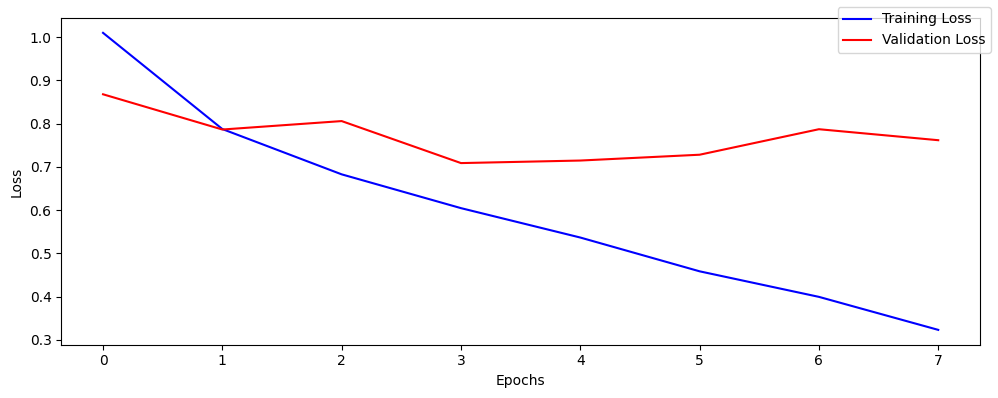

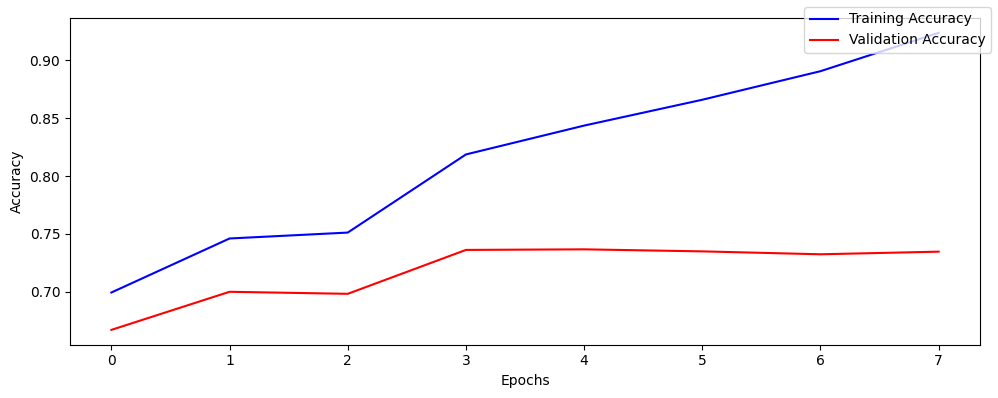

In [36]:
mb_m2_norm.plot_losses()
mb_m2_norm.plot_accuracies()

These results display how the normalisation is very beneficial in helping optimisation, the training loss was falling significantly quicker with even less epochs being needed to get to the same loss result. The model already fell below the required loss by 4 epochs.

This shows how the inputs have been stabilised, however, the generalisation has not really improved and the overfitting problems that were occuring before are still very present.

Since the following evaluation process of caluculating matrices and accuracies is being repeated so much it might be more sensible to wrap these steps in a function. This will be placed in the functions folder and called instead. This probably would have been more time efficient to introduce sooner but it is beneficial to see which variables are changing each time in the step by step process as well.

m2 with normalisation Accuracy: 0.7347


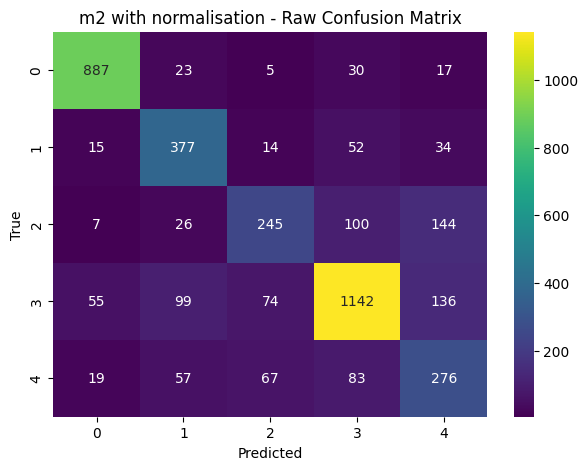

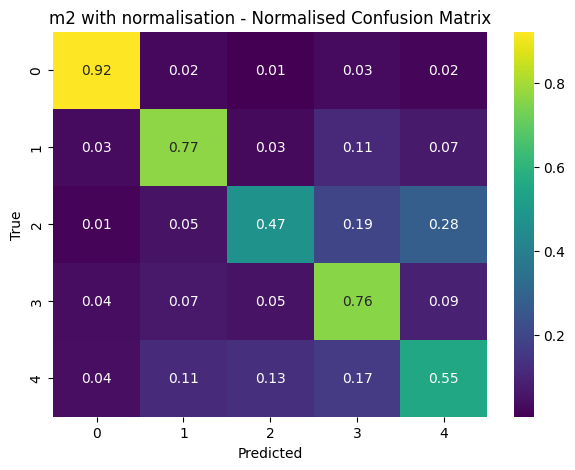

In [37]:
importlib.reload(functions)

acc_m2_norm, raw, norm = functions.evaluate_and_plot(
    m2_norm,
    val_norm_loader,
    mb_m2_norm.device,
    title_prefix="m2 with normalisation"
)

These matrices show:
- class 0 is still consistenly good.
- class 1 has improved, with a score of 77% compared to the previous 60%, with less confusion with the other animal classes.
- class 2 unfortunately remained unstable with heavy confusions still occuring with class 3 and 4.
- A small decrease with class 3, possibly due to a reduced bias towards this dominate animal class.
- class 4 improved! This class recieved an accuracy of 55%, significantly better than before with 44% and also better than the deeper model which only got up to 49%. This shows how normalisation was valuable in learing more balanced feature scales.

These matrices show a increase in accuracy through reducing issues between classes with subtle texture differences, producing an overall more balanced model through a more stable training process. However, the deeper issues and overlaps with the cat and dog classes were still very present.


#### 6.2 Using WeightedRandomSamper to Manage Class Imbalance

In [38]:
importlib.reload(functions)

train_y = torch.tensor([train_norm_v2[i][1] for i in range(len(train_norm_v2))])
sampler = functions.weighted_sampler(train_y, mb_m2_norm.device)

train_sampler_loader = DataLoader(
    train_norm_v2,
    batch_size=batch_size,
    sampler=sampler
)


In [39]:
# test to perform check on batch frequences before and after
for images, labels in train_sampler_loader:
    print("frequencies:", Counter(labels.tolist()))
    break

frequencies: Counter({4: 17, 0: 14, 2: 12, 1: 11, 3: 10})


This code clearly demonstrated how this method has evened the classes out significantly in their frequencies compared to the intital frequences, where there was a count difference of 21 between the most frequent class (class 3), and the least frequent (class 2). Not are they more balanced, but class 3 is not dominating as much as it was previously either, with it consistently not being the most frequent class when this code was rerun.

In [46]:
m2_sampler = nn.Sequential(
     nn.Conv2d(3, 32, kernel_size=3, padding=1),
     nn.ReLU(),
     nn.MaxPool2d(2,2),

     nn.Conv2d(32, 64, kernel_size=3, padding=1),
     nn.ReLU(),
     nn.MaxPool2d(2,2),

     nn.Flatten(),
     nn.Linear(64*8*8, 512),
     nn.ReLU(),
     nn.Linear(512, 5)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(m2_sampler.parameters(), lr=0.0001)

mb_m2_sampler = ModelBuilder(m2_sampler, loss_fn, optimizer, print_loss_freq=2)
mb_m2_sampler.set_loaders(train_sampler_loader, val_norm_loader)

history_sampler = mb_m2_sampler.train(
    n_epochs=24,
    seed=42
)


Epoch 2, Training loss 1.0104, Validation loss 0.9716
Epoch 4, Training loss 0.8756, Validation loss 0.9019
Epoch 6, Training loss 0.8010, Validation loss 0.9502
Epoch 8, Training loss 0.7378, Validation loss 0.8332
Epoch 10, Training loss 0.6641, Validation loss 0.7761
Epoch 12, Training loss 0.6133, Validation loss 0.8178
Epoch 14, Training loss 0.5574, Validation loss 0.7998
Epoch 16, Training loss 0.5060, Validation loss 0.7488
Epoch 18, Training loss 0.4603, Validation loss 0.8394
Epoch 20, Training loss 0.4034, Validation loss 0.7722
Epoch 22, Training loss 0.3663, Validation loss 0.7582
Epoch 24, Training loss 0.3154, Validation loss 0.7806


Although the training batches were balanced effectively, this did not actually result in an improvement to the loss or accuracy. Additionally, this model was also taking a bit longer to train, however this training was more balanced, plateauing more consistently instead of increasing, this plateau can be seen clearly below.

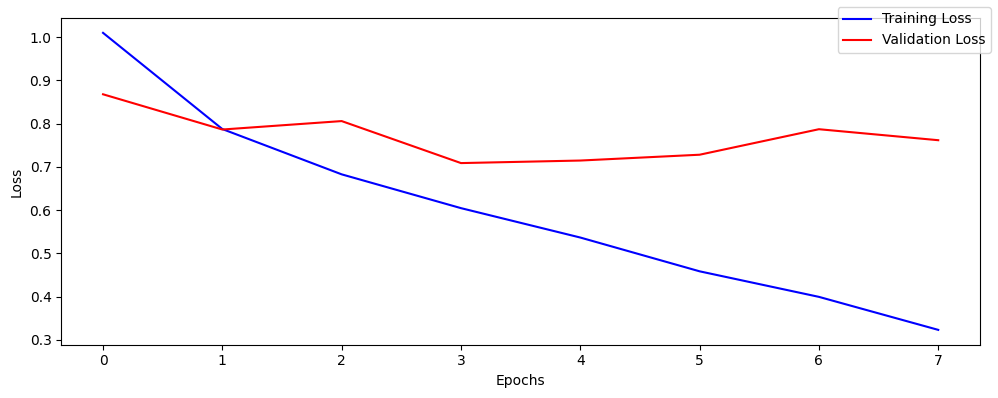

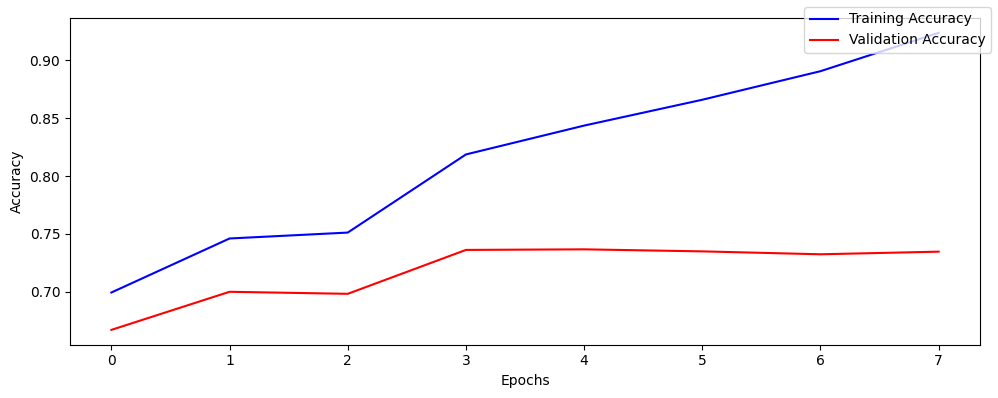

In [47]:
mb_m2_norm.plot_losses()
mb_m2_norm.plot_accuracies()

m2 with WeightedSampler Accuracy: 0.7226


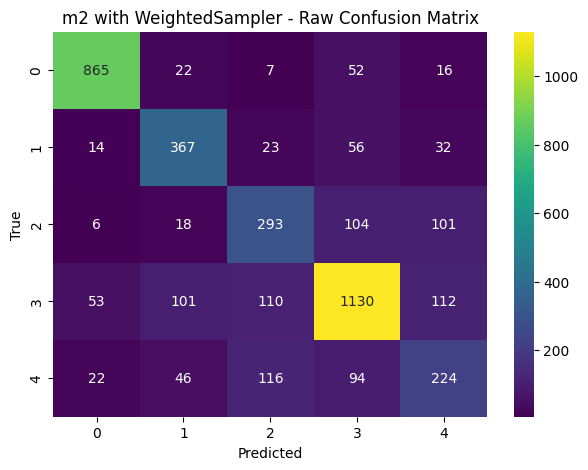

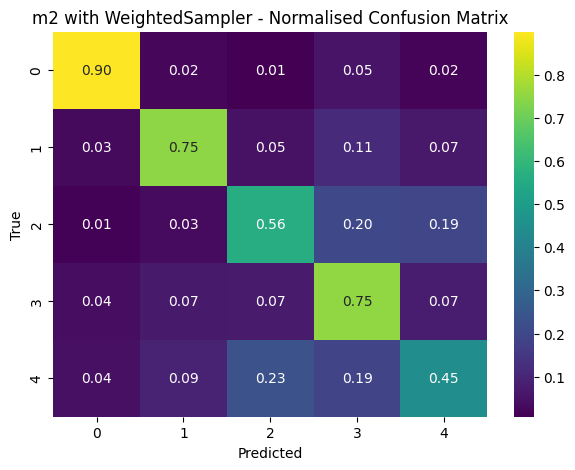

In [48]:
acc_samp, raw_samp, norm_samp = functions.evaluate_and_plot(
    m2_sampler,
    val_norm_loader,
    mb_m2_sampler.device,
    title_prefix="m2 with WeightedSampler"
)

These matrices show that *WeightedSampling* better represented some of the under represented classes, with class 2 performing a lot more accurately than it did with just the normalisation, offsetting the issue of class 2 being overwhelmed by the larger animal classes.

Unfortunately, class 4 ended up decreasing in accuracy from the normalisation model.

The raw confusion matrix still remains unbalanced because this function does not change the class distrivution in the validation set, so the normalised confusion matrix provides a more fair analysis of the changes in class performance.

#### 6.3 Applying Regularisation Through Dropout Layers

This will be evaluated seperately to the sampler so that a deeper understanding of the results can be formed, with minimisation of other impacting variables. This is very simple to implement, with a dropout layer just being introduced before the final linear layer, 0.5 was chosen as this value is commonly very balanced for dropout layers, and will hopefully minimise overfitting whilstallowing the network to learn effectively.

In [52]:
m2_dropout = nn.Sequential(
     nn.Conv2d(3, 32, kernel_size=3, padding=1),
     nn.ReLU(),
     nn.MaxPool2d(2,2),

     nn.Conv2d(32, 64, kernel_size=3, padding=1),
     nn.ReLU(),
     nn.MaxPool2d(2,2),

     nn.Flatten(),
     nn.Linear(64*8*8, 512),
     nn.ReLU(),
     nn.Dropout(0.5),
     nn.Linear(512, 5)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(m2_dropout.parameters(), lr=0.0005)

mb_m2_dropout = ModelBuilder(
    m2_dropout,
    loss_fn,
    optimizer,
    print_loss_freq=1
)

mb_m2_dropout.set_loaders(train_norm_loader, val_norm_loader)

history_drop = mb_m2_dropout.train(
    n_epochs=8,
    seed=42
)

Epoch 1, Training loss 1.0532, Validation loss 0.8851
Epoch 2, Training loss 0.8420, Validation loss 0.8136
Epoch 3, Training loss 0.7494, Validation loss 0.8245
Epoch 4, Training loss 0.6830, Validation loss 0.7276
Epoch 5, Training loss 0.6156, Validation loss 0.7040
Epoch 6, Training loss 0.5599, Validation loss 0.7035
Epoch 7, Training loss 0.5057, Validation loss 0.7193
Epoch 8, Training loss 0.4544, Validation loss 0.6678


This shows how the dropout slowed training intitally through the effect of noise, but was overall more stable, producing one of the best validation loss results so far: 0.66.

This shows an effective reduction in overfitting and an improvement in generalisation.

m2 + Dropout Accuracy: 0.7508


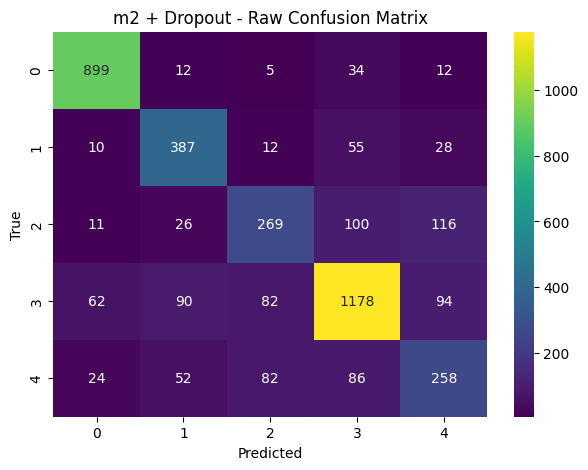

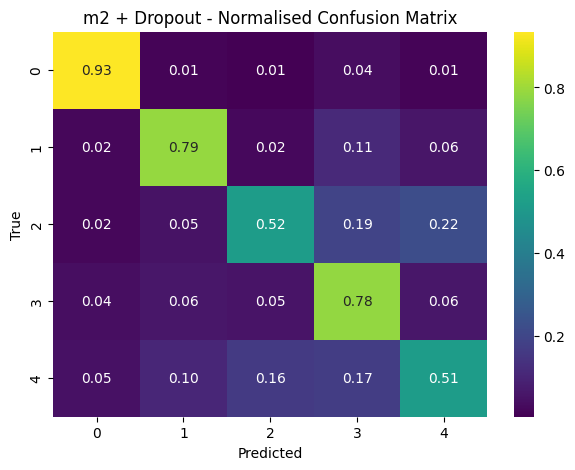

In [53]:
acc_drop, raw_drop, norm_drop = functions.evaluate_and_plot(
    m2_dropout,
    val_norm_loader,
    mb_m2_dropout.device,
    title_prefix="m2 + Dropout"
)


This dropout, through preventing overfitting, did not decrease the accuracy results. This correction led to improvements for the more midsized classes, class 1 and 4, which were previously getting lost through the model overfitting to the dominant animal class.

This has been the most effective class so far.

Through resuming this model for 6 more epochs, the stability can also be portrayed. Although the model does eventually overfit again, this occurs at a significantly slower pace then the previous models. This is very positive considering this was one of the biggest issues so far.

In [54]:
more_history = mb_m2_dropout.train(
    n_epochs=6,   # another 6 epochs
    seed=42
)

Epoch 1, Training loss 0.3703, Validation loss 0.7893
Epoch 2, Training loss 0.3243, Validation loss 0.7304
Epoch 3, Training loss 0.2700, Validation loss 0.7422
Epoch 4, Training loss 0.2169, Validation loss 0.8121
Epoch 5, Training loss 0.1722, Validation loss 0.8129
Epoch 6, Training loss 0.1564, Validation loss 0.9141


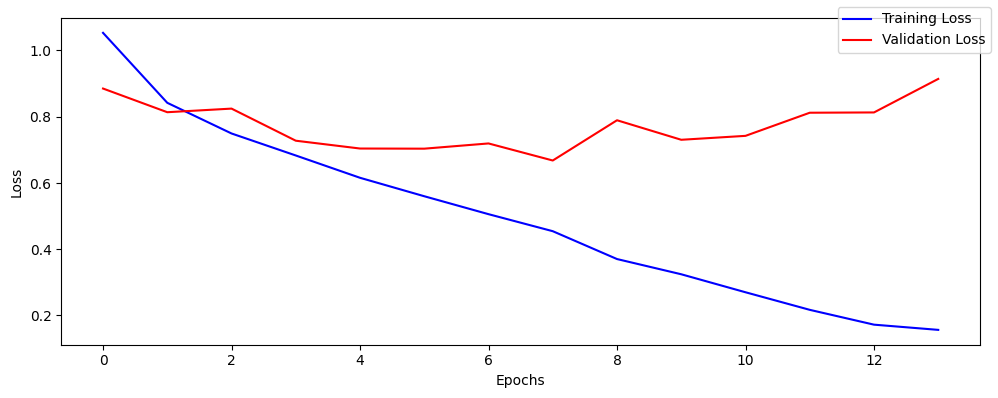

In [55]:
mb_m2_dropout.plot_losses()

This graph shows how the training loss drops significantly slower and the validation loss rises a lot less quickly.

#### 6.4 Modifying the Pooling Layers

To experiement with the pooling layers, an additional final pooling layer will be introduced to reduce the spatial size even further.

In [59]:
m2_pool = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.AvgPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(64*4*4, 256),
    nn.ReLU(),
    nn.Linear(256, 5)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(m2_pool.parameters(), lr=0.0005)

mb_m2_pool = ModelBuilder(
    m2_pool,
    loss_fn,
    optimizer,
    print_loss_freq=2
)

mb_m2_pool.set_loaders(train_norm_loader, val_norm_loader)

history_pool = mb_m2_pool.train(
    n_epochs=16,
    seed=42
)


Epoch 2, Training loss 0.8862, Validation loss 0.8562
Epoch 4, Training loss 0.7677, Validation loss 0.7727
Epoch 6, Training loss 0.6916, Validation loss 0.7545
Epoch 8, Training loss 0.6297, Validation loss 0.7106
Epoch 10, Training loss 0.5666, Validation loss 0.6807
Epoch 12, Training loss 0.5233, Validation loss 0.6823
Epoch 14, Training loss 0.4837, Validation loss 0.6691
Epoch 16, Training loss 0.4303, Validation loss 0.6673


m2 and pooling addition Accuracy: 0.7487


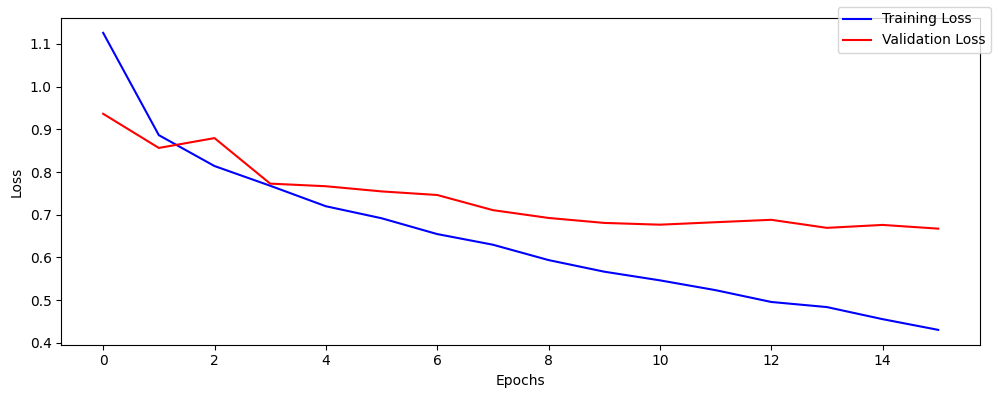

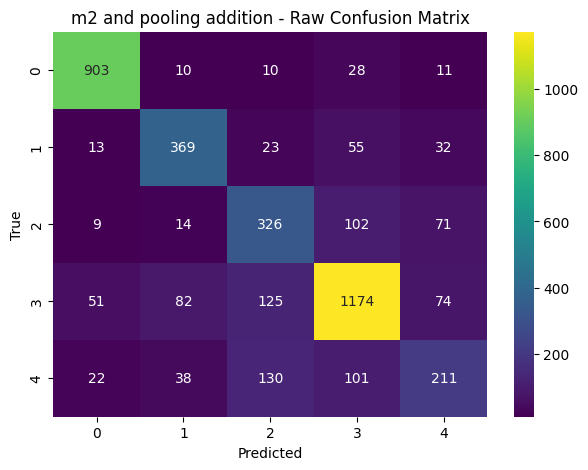

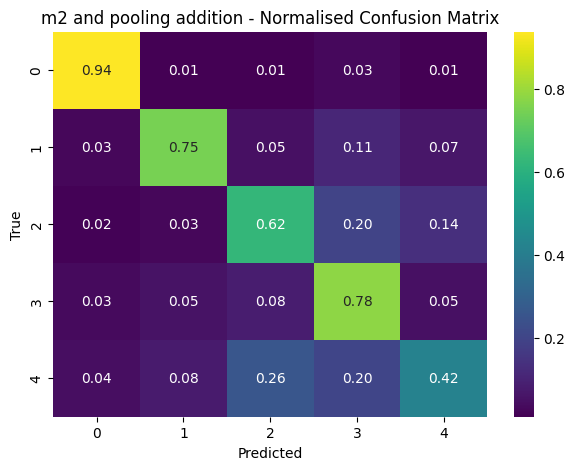

In [60]:
mb_m2_pool.plot_losses()

acc_pool, raw_pool, norm_pool = functions.evaluate_and_plot(
    m2_pool,
    val_norm_loader,
    mb_m2_pool.device,
    title_prefix="m2 and pooling addition"
)

This model has ended up being one of the most stable versions of m2 so far, the loss graph is significantly the smoothest so far, with no serious overfitting trend visible despite it being a bit of a higher amount of epochs. This shows that the training loss is not just dropping less dramatically, but also at a slower pace.

The validation loss and the training loss shapes are a lot more similar showing how this pooling layer has significantly reduced the previous impacts of overfitting.

The confusion matrix shows one of the best results for class 2 so far, with an accuracy result of 62%, showing how the pooling is maintaining the high-level structure needed to categorise this class. Class 0, 2, and 3 have all remained very strong and consistent. It is good that the benefits in class 2, did not have a trade off for these other classes.

Unfortunately, class 4 is still performing quite low, but this is due to the dataset and the class categorisations making this a harder class to recognise, especially since this pooling is probably removing the high-level detail and finer textures that are really essential for this class.

## 7.0 Conclusion
This assignment has been beneficial in displaying the implementation and evaluation of neural networks through classifying images and creating matrices and graphs.

Overall, there was a significant problem recognised with the classification of class 4 across all of the models. Through techniques used to reduce overfitting and other problems the rest of the classes improved noticeably. The overlap of this cat class being confused with the other animal classes was present throughout the whole assignment.

Class 0, predictably due to its clear distiction from the animal classes, as it instead contained automobiles and trucks, significantly performed the best.

It would be interesting to apply similar models, with the same thinking, to classes with more distiction between them visually, to see if all the classes are able to perform effectively.

## 8.0 References

Ganichev, A. (2021) How to calculate the mean and the std of CIFAR10 data. Available at: https://stackoverflow.com/questions/66678052/how-to-calculate-the-mean-and-the-std-of-cifar10-data
 (Accessed: 15 November 2025).